# Part One: DistilRoBERTa and RoBERTa classification

# 1. Setting up the models

In [46]:
!pip install transformers
!pip install opendatasets
!pip install pandas

In [47]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import numpy as np

from transformers import pipeline

DistilRoBERTa_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    tokenizer="j-hartmann/emotion-english-distilroberta-base",
    device=-1
)


RoBERTa_classifier = pipeline(
    task="text-classification",
    model="SamLowe/roberta-base-go_emotions",
    tokenizer="SamLowe/roberta-base-go_emotions",
    device=-1,
    top_k=None)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 2. Importing the dataset

In [48]:
import opendatasets as od
import pandas

od.download(
    "https://www.kaggle.com/datasets/mexwell/poem-dataset")

Skipping, found downloaded files in "./poem-dataset" (use force=True to force download)


In [49]:
import pandas as pds

file =('/content/poem-dataset/final_df_emotions(remove-bias).csv')
newData = pds.read_csv(file)

newData.head()

,poem content,pred,label,score,anger,disgust,fear,joy,neutral,sadness,surprise,age,type
0,Let the bird of loudest lay\r\nOn the sole Ara...,5,sadness,0.650738,0.133402,0.076618,0.094706,0.006762,0.032960,0.650738,0.004814,Renaissance,Mythology & Folklore
1,"Sir Charles into my chamber coming in,\r\nWhen...",0,anger,0.264296,0.264296,0.145707,0.057977,0.262715,0.019884,0.244457,0.004963,Renaissance,Mythology & Folklore
2,"Our vice runs beyond all that old men saw,\r\n...",0,anger,0.758054,0.758054,0.210444,0.003690,0.001755,0.013997,0.011483,0.000578,Renaissance,Mythology & Folklore
3,"Lo I the man, whose Muse whilome did maske,\r\...",0,anger,0.896280,0.896280,0.009259,0.004949,0.002320,0.007623,0.078088,0.001481,Renaissance,Mythology & Folklore
4,"Long have I longd to see my love againe,\r\nSt...",5,sadness,0.600543,0.027077,0.036344,0.075487,0.017212,0.187106,0.600543,0.056230,Renaissance,Mythology & Folklore


In [50]:
poem_content = newData['poem content']

display(poem_content.head())

,poem content
0,Let the bird of loudest lay\r\nOn the sole Ara...
1,"Sir Charles into my chamber coming in,\r\nWhen..."
2,"Our vice runs beyond all that old men saw,\r\n..."
3,"Lo I the man, whose Muse whilome did maske,\r\..."
4,"Long have I longd to see my love againe,\r\nSt..."


In [51]:
first_poem = poem_content.iloc[100]
first_label = newData['label'].iloc[100]

display(first_poem)
display(first_label)

'Forget not yet the tried intent\r\nOf such a truth as I have meant;\r\nMy great travail so gladly spent,\r\n            Forget not yet.\r\n\r\n   Forget not yet when first began\r\nThe weary life ye know, since whan\r\nThe suit, the service, none tell can;\r\n            Forget not yet.\r\n\r\n   Forget not yet the great assays,\r\nThe cruel wrong, the scornful ways;\r\nThe painful patience in denays,\r\n            Forget not yet.\r\n\r\n   Forget not yet, forget not this,\r\nHow long ago hath been and is\r\nThe mind that never meant amiss;\r\n            Forget not yet.\r\n\r\n   Forget not then thine own approved,\r\nThe which so long hath thee so loved,\r\nWhose steadfast faith yet never moved;\r\n            Forget not this.'

'sadness'

# 3. Making predictions

In [52]:
import numpy as np

true = newData['label']

samples = newData['poem content']
samples = [s.replace('\r\n', '\n').strip() for s in samples]



DistilRoBERTa_pred_labels = []
for s in samples:
    result = DistilRoBERTa_classifier(
        s,
        truncation=True,
        padding=True
    )
    DistilRoBERTa_pred_labels.append(result[0]['label'])



In [53]:
RoBERTa_pred_labels = []

RoBERTa_classifier(first_poem)


for s in samples:
    result = RoBERTa_classifier(
        s,
        truncation=True,
        padding=True
    )
    RoBERTa_pred_labels.append(result[0][0]['label'])

# 4. Mapping and Metrics

{'f1': 0.8907470321224287, 'accuracy': 0.9111111111111111, 'precision': 0.88440635512776, 'recall': 0.8999324246851146, 'weighted f1': 0.9116109787946534}
{'f1': 0.10657555491780334, 'accuracy': 0.12666666666666668, 'precision': 0.28962463236331093, 'recall': 0.21565934065934064, 'weighted f1': 0.09029426779377311}


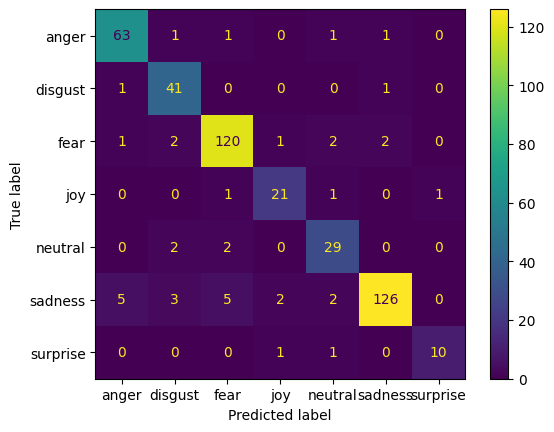

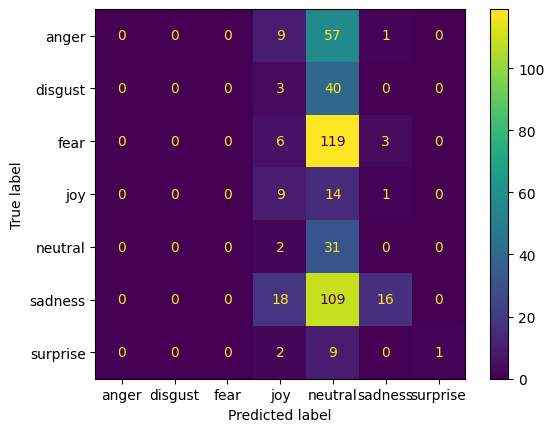

In [54]:
from sklearn import metrics


label_map = {
    'admiration': 'joy',
    'amusement': 'joy',
    'anger': 'anger',
    'annoyance': 'anger',
    'approval': 'joy',
    'caring': 'joy',
    'confusion': 'neutral',
    'curiosity': 'joy',
    'desire': 'joy',
    'disappointment': 'sadness',
    'disapproval': 'disgust',
    'disgust': 'disgust',
    'embarrassment': 'fear',
    'excitement': 'joy',
    'fear': 'fear',
    'gratitude': 'joy',
    'grief': 'sadness',
    'joy': 'joy',
    'love': 'joy',
    'nervousness': 'fear',
    'optimism': 'joy',
    'pride': 'joy',
    'realization': 'surprise',
    'relief': 'joy',
    'remorse': 'sadness',
    'sadness': 'sadness',
    'surprise': 'surprise',
    'neutral': 'neutral',
}

RoBERTa_pred_labels = [label_map[p] for p in RoBERTa_pred_labels]
poem_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

def pred_metrics(true, pred):
    return {
        "f1": metrics.f1_score(true, pred, zero_division=0, average="macro"),
        "accuracy": metrics.accuracy_score(true, pred),
        "precision": metrics.precision_score(true, pred, zero_division=0, average="macro"),
        "recall": metrics.recall_score(true, pred, zero_division=0, average="macro"),
        "weighted f1": metrics.f1_score(true, pred, zero_division=0, average="weighted"),
    }

print(pred_metrics(true, DistilRoBERTa_pred_labels))
print(pred_metrics(true, RoBERTa_pred_labels))

DistilRoBERTa_labels = [DistilRoBERTa_classifier.model.config.id2label[i]
          for i in range(len(DistilRoBERTa_classifier.model.config.id2label))]

DistilRoBERTa_cm = metrics.confusion_matrix(true, DistilRoBERTa_pred_labels, labels=DistilRoBERTa_labels)
RoBERTa_cm = metrics.confusion_matrix(true, RoBERTa_pred_labels, labels=poem_labels)

DistilRoBERTa_disp = metrics.ConfusionMatrixDisplay(DistilRoBERTa_cm, display_labels=DistilRoBERTa_labels)
DistilRoBERTa_disp.plot()

RoBERTa_disp = metrics.ConfusionMatrixDisplay(RoBERTa_cm, display_labels=poem_labels)
RoBERTa_disp.plot()

# Part Two: Fine tuning DistilBERT and RoBERTa using dataset

### 1. Data Preparation for Fine-Tuning
We'll use the `datasets` library to convert our DataFrame and `LabelEncoder` to handle the target classes.

In [25]:
!pip install datasets

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Map our text labels to integers
le = LabelEncoder()
newData['label_num'] = le.fit_transform(newData['label'])
label_list = le.classes_.tolist()

# Split into training and validation sets
train_df, val_df = train_test_split(newData, test_size=0.15, random_state=42)

train_dataset = Dataset.from_pandas(train_df[['poem content', 'label_num']])
val_dataset = Dataset.from_pandas(val_df[['poem content', 'label_num']])

### 2. Tokenization and Model Setup
We will initialize the base models and tokenize the poem content.

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

def get_tokenized_dataset(model_name, dataset):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_func(examples):
        result = tokenizer(examples['poem content'], padding='max_length', truncation=True)
        result['labels'] = examples['label_num']
        return result
    return dataset.map(tokenize_func, batched=True), tokenizer

# Setup for DistilBERT
db_model_name = "distilbert-base-uncased"
train_db, db_tokenizer = get_tokenized_dataset(db_model_name, train_dataset)
val_db, _ = get_tokenized_dataset(db_model_name, val_dataset)

# Setup for RoBERTa
rb_model_name = "roberta-base"
train_rb, rb_tokenizer = get_tokenized_dataset(rb_model_name, train_dataset)
val_rb, _ = get_tokenized_dataset(rb_model_name, val_dataset)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/382 [00:00<?, ? examples/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/382 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

### 3. Fine-Tuning Execution
Now we define the Trainer and start the training process for DistilBERT. (We can repeat this for RoBERTa next).

In [27]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return pred_metrics(le.inverse_transform(labels), le.inverse_transform(predictions))

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
)

# Initialize DistilBERT for Fine-Tuning
ft_distilbert = AutoModelForSequenceClassification.from_pretrained(db_model_name, num_labels=len(label_list))

trainer_db = Trainer(
    model=ft_distilbert,
    args=training_args,
    train_dataset=train_db,
    eval_dataset=val_db,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for DistilBERT...")
trainer_db.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for DistilBERT...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.689141,0.065681,0.294118,0.042644,0.142857,0.135227
2,No log,1.615030,0.134526,0.382353,0.109869,0.185714,0.276965
3,No log,1.557292,0.158785,0.441176,0.126160,0.214286,0.326909
4,No log,1.529561,0.158632,0.441176,0.126292,0.214286,0.326595
5,No log,1.516971,0.163744,0.455882,0.130576,0.221429,0.337120
6,No log,1.526253,0.145292,0.411765,0.117965,0.200000,0.299131
7,No log,1.533857,0.145566,0.411765,0.119255,0.200000,0.299695
8,No log,1.523506,0.177482,0.426471,0.262690,0.215873,0.333051
9,No log,1.522022,0.165796,0.397059,0.254422,0.201587,0.308992
10,No log,1.509622,0.183058,0.441176,0.266538,0.223016,0.344530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=240, training_loss=1.3189554850260417, metrics={'train_runtime': 82.1099, 'train_samples_per_second': 46.523, 'train_steps_per_second': 2.923, 'total_flos': 506070584094720.0, 'train_loss': 1.3189554850260417, 'epoch': 10.0})

### 4. Fine-Tuning RoBERTa
We will now follow the same process to fine-tune the `roberta-base` model.

In [28]:
ft_roberta = AutoModelForSequenceClassification.from_pretrained(rb_model_name, num_labels=len(label_list))

trainer_rb = Trainer(
    model=ft_roberta,
    args=training_args,
    train_dataset=train_rb,
    eval_dataset=val_rb,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for RoBERTa...")
trainer_rb.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for RoBERTa...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.675425,0.065681,0.294118,0.042644,0.142857,0.135227
2,No log,1.588354,0.103203,0.323529,0.090709,0.157143,0.212478
3,No log,1.506433,0.148182,0.411765,0.120680,0.200000,0.305081
4,No log,1.396491,0.205574,0.470588,0.226399,0.242857,0.377992
5,No log,1.310773,0.309979,0.485294,0.409107,0.306349,0.434761
6,No log,1.329583,0.257136,0.470588,0.300144,0.284921,0.405932
7,No log,1.297184,0.320810,0.485294,0.309524,0.376190,0.429399
8,No log,1.230699,0.335426,0.485294,0.437758,0.342063,0.456520
9,No log,1.223616,0.364856,0.529412,0.481927,0.363492,0.489674
10,No log,1.215023,0.356798,0.514706,0.470776,0.356349,0.478981


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=240, training_loss=1.1035424550374349, metrics={'train_runtime': 168.8596, 'train_samples_per_second': 22.622, 'train_steps_per_second': 1.421, 'total_flos': 1005129352704000.0, 'train_loss': 1.1035424550374349, 'epoch': 10.0})

### 5. Final Evaluation
Once training is complete, we should evaluate all four models on the validation set to compare results.

In [29]:
print("DistilBERT Fine-tuned Metrics:")
display(trainer_db.evaluate())

print("\nRoBERTa Fine-tuned Metrics:")
display(trainer_rb.evaluate())

DistilBERT Fine-tuned Metrics:


{'eval_loss': 1.5096218585968018,
 'eval_f1': 0.18305764411027567,
 'eval_accuracy': 0.4411764705882353,
 'eval_precision': 0.2665379665379665,
 'eval_recall': 0.22301587301587303,
 'eval_weighted f1': 0.34453044375645,
 'eval_runtime': 0.5118,
 'eval_samples_per_second': 132.872,
 'eval_steps_per_second': 17.586,
 'epoch': 10.0}


RoBERTa Fine-tuned Metrics:


{'eval_loss': 1.2150230407714844,
 'eval_f1': 0.35679779158040026,
 'eval_accuracy': 0.5147058823529411,
 'eval_precision': 0.4707758907758908,
 'eval_recall': 0.35634920634920636,
 'eval_weighted f1': 0.4789814476515244,
 'eval_runtime': 0.966,
 'eval_samples_per_second': 70.395,
 'eval_steps_per_second': 9.317,
 'epoch': 10.0}

### 6. Summary Comparison of All Models
We will now collect the metrics from all four models to see how the pre-trained zero-shot models compare against the fine-tuned ones.

,DistilRoBERTa (Pre-trained),RoBERTa (Pre-trained),DistilBERT (Fine-tuned),RoBERTa (Fine-tuned)
Macro F1,0.890747,0.106576,0.183058,0.356798
Accuracy,0.911111,0.126667,0.441176,0.514706
Weighted F1,0.911611,0.090294,0.344530,0.478981


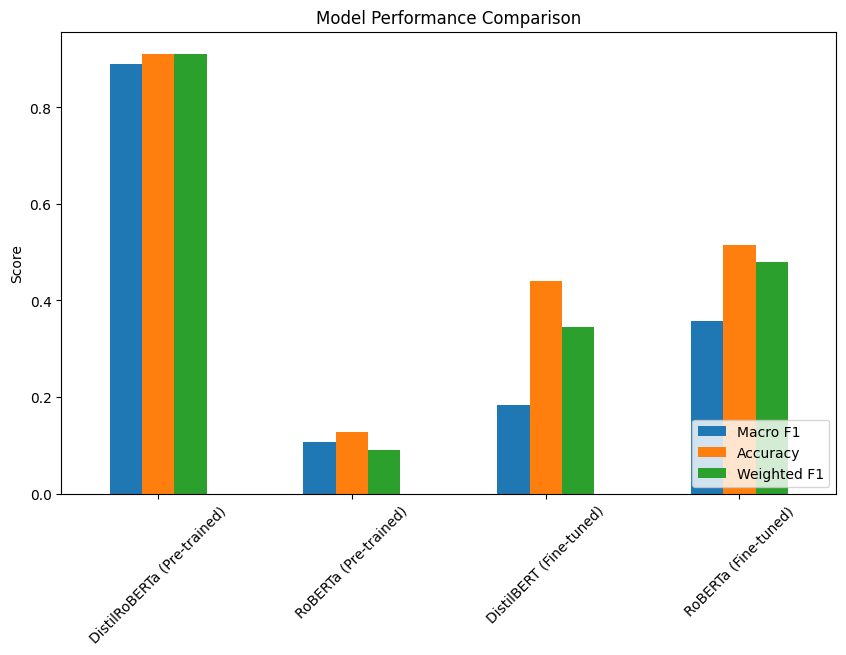

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Collect Pre-trained Metrics (already calculated earlier in notebook)
pre_trained_drb = pred_metrics(true, DistilRoBERTa_pred_labels)
pre_trained_rb = pred_metrics(true, RoBERTa_pred_labels)

# 2. Collect Fine-tuned Metrics
ft_db_results = trainer_db.evaluate()
ft_rb_results = trainer_rb.evaluate()

# Simplify keys for comparison
data = {
    "DistilRoBERTa (Pre-trained)": [pre_trained_drb['f1'], pre_trained_drb['accuracy'], pre_trained_drb['weighted f1']],
    "RoBERTa (Pre-trained)": [pre_trained_rb['f1'], pre_trained_rb['accuracy'], pre_trained_rb['weighted f1']],
    "DistilBERT (Fine-tuned)": [ft_db_results['eval_f1'], ft_db_results['eval_accuracy'], ft_db_results['eval_weighted f1']],
    "RoBERTa (Fine-tuned)": [ft_rb_results['eval_f1'], ft_rb_results['eval_accuracy'], ft_rb_results['eval_weighted f1']]
}

comparison_df = pd.DataFrame(data, index=['Macro F1', 'Accuracy', 'Weighted F1'])

display(comparison_df)

# Plotting
comparison_df.T.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

### Confusion Matrices for Fine-Tuned Models
We'll now visualize where the fine-tuned models are succeeding or confusing specific poetic emotions.

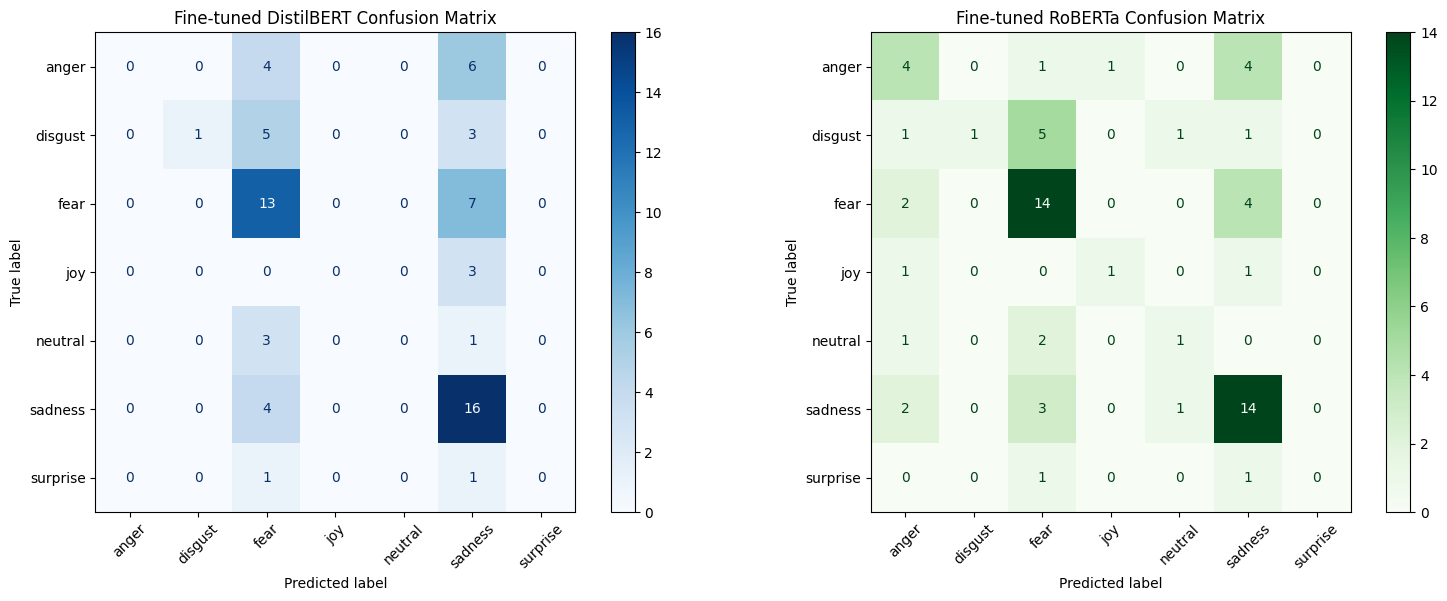

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(trainer, dataset):
    predictions = trainer.predict(dataset)
    return np.argmax(predictions.predictions, axis=-1)

# Get predictions
ft_db_preds = get_predictions(trainer_db, val_db)
ft_rb_preds = get_predictions(trainer_rb, val_rb)

# Get true labels from validation set
y_true = val_df['label_num'].values

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# DistilBERT CM
cm_db = confusion_matrix(y_true, ft_db_preds)
disp_db = ConfusionMatrixDisplay(confusion_matrix=cm_db, display_labels=label_list)
disp_db.plot(ax=ax1, cmap='Blues', xticks_rotation=45)
ax1.set_title("Fine-tuned DistilBERT Confusion Matrix")

# RoBERTa CM
cm_rb = confusion_matrix(y_true, ft_rb_preds)
disp_rb = ConfusionMatrixDisplay(confusion_matrix=cm_rb, display_labels=label_list)
disp_rb.plot(ax=ax2, cmap='Greens', xticks_rotation=45)
ax2.set_title("Fine-tuned RoBERTa Confusion Matrix")

plt.tight_layout()
plt.show()

# Part 3: Augmenting Data
Because our dataset only contains 450 poems, we will augment the dataset, comparing how the models perform on Synonym augmentation versus Back Translation augmentation.

# 1. Wordnet Synonynm Augmentation

In [55]:
!pip install nlpaug nltk
import nltk
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

import nlpaug.augmenter.word as naw

augmenter = naw.SynonymAug(aug_src='wordnet')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 29.4 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [56]:
from tqdm import tqdm

def augment_dataframe(df, augmenter, text_col='poem content'):
    augmented_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        augmented_text = augmenter.augment(row[text_col])[0]
        augmented_rows.append({
            'poem content': augmented_text,
            'label_num': row['label_num']
        })
    augmented_df = pds.DataFrame(augmented_rows)
    return pds.concat([df, augmented_df], ignore_index=True)

train_df_augmented = augment_dataframe(train_df, augmenter)

train_dataset = Dataset.from_pandas(train_df_augmented[['poem content', 'label_num']])
val_dataset = Dataset.from_pandas(val_df[['poem content', 'label_num']])

100%|██████████| 382/382 [00:03<00:00, 120.16it/s]


In [57]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

def get_tokenized_dataset(model_name, dataset):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_func(examples):
        result = tokenizer(examples['poem content'], padding='max_length', truncation=True)
        result['labels'] = examples['label_num']
        return result
    return dataset.map(tokenize_func, batched=True), tokenizer

# Setup for DistilBERT
db_model_name = "distilbert-base-uncased"
train_db, db_tokenizer = get_tokenized_dataset(db_model_name, train_dataset)
val_db, _ = get_tokenized_dataset(db_model_name, val_dataset)

# Setup for RoBERTa
rb_model_name = "roberta-base"
train_rb, rb_tokenizer = get_tokenized_dataset(rb_model_name, train_dataset)
val_rb, _ = get_tokenized_dataset(rb_model_name, val_dataset)

Map:   0%|          | 0/764 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/764 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

In [59]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return pred_metrics(le.inverse_transform(labels), le.inverse_transform(predictions))

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
)

# Initialize DistilBERT for Fine-Tuning
wordnet_ft_distilbert = AutoModelForSequenceClassification.from_pretrained(db_model_name, num_labels=len(label_list))

wordnet_trainer_db = Trainer(
    model=wordnet_ft_distilbert,
    args=training_args,
    train_dataset=train_db,
    eval_dataset=val_db,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for DistilBERT...")
wordnet_trainer_db.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for DistilBERT...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.594079,0.153571,0.426471,0.123469,0.207143,0.316176
2,No log,1.556409,0.157483,0.441176,0.127159,0.214286,0.324231
3,No log,1.506322,0.177482,0.426471,0.262690,0.215873,0.333051
4,No log,1.510956,0.250943,0.500000,0.358142,0.273016,0.429146
5,No log,1.676264,0.188906,0.411765,0.315476,0.215873,0.335225
6,No log,1.534797,0.313577,0.500000,0.565637,0.306349,0.439228
7,No log,1.581208,0.382440,0.529412,0.575893,0.363492,0.486232
8,No log,1.671353,0.412860,0.529412,0.661565,0.384921,0.490325
9,No log,1.699850,0.420238,0.544118,0.610712,0.399206,0.504185
10,No log,1.725551,0.374137,0.514706,0.602041,0.349206,0.471472


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=480, training_loss=0.7334388097127279, metrics={'train_runtime': 160.0286, 'train_samples_per_second': 47.741, 'train_steps_per_second': 2.999, 'total_flos': 1012141168189440.0, 'train_loss': 0.7334388097127279, 'epoch': 10.0})

In [60]:
wordnet_ft_roberta = AutoModelForSequenceClassification.from_pretrained(rb_model_name, num_labels=len(label_list))

wordnet_trainer_rb = Trainer(
    model=wordnet_ft_roberta,
    args=training_args,
    train_dataset=train_rb,
    eval_dataset=val_rb,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for RoBERTa...")
wordnet_trainer_rb.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for RoBERTa...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.633111,0.157823,0.441176,0.128372,0.214286,0.324930
2,No log,1.455457,0.151566,0.411765,0.122186,0.200000,0.312048
3,No log,1.339605,0.339438,0.455882,0.433571,0.342063,0.450918
4,No log,1.332639,0.347533,0.544118,0.447527,0.389683,0.499332
5,No log,1.371886,0.397561,0.544118,0.555736,0.379365,0.530108
6,No log,1.318851,0.412920,0.588235,0.500411,0.407937,0.558953
7,No log,1.432822,0.470938,0.573529,0.572234,0.436508,0.569348
8,No log,1.376943,0.569952,0.632353,0.710031,0.519841,0.650739
9,No log,1.507017,0.517529,0.632353,0.733242,0.484921,0.597691
10,No log,1.456141,0.572568,0.647059,0.741771,0.518254,0.644235


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=480, training_loss=0.6362691243489583, metrics={'train_runtime': 326.2934, 'train_samples_per_second': 23.415, 'train_steps_per_second': 1.471, 'total_flos': 2010258705408000.0, 'train_loss': 0.6362691243489583, 'epoch': 10.0})

# 2. Back Translantion

In [61]:
augmenter = naw.BackTranslationAug(
    from_model_name='Helsinki-NLP/opus-mt-en-fr',
    to_model_name='Helsinki-NLP/opus-mt-fr-en',
    batch_size=8
)

train_df_augmented = augment_dataframe(train_df, augmenter)

train_dataset = Dataset.from_pandas(train_df_augmented[['poem content', 'label_num']])
val_dataset = Dataset.from_pandas(val_df[['poem content', 'label_num']])

train_df_augmented.to_csv('augmented_train.csv', index=False)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

100%|██████████| 382/382 [47:29<00:00,  7.46s/it]


In [62]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return pred_metrics(le.inverse_transform(labels), le.inverse_transform(predictions))

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.05,
)

# Initialize DistilBERT for Fine-Tuning
bt_ft_distilbert = AutoModelForSequenceClassification.from_pretrained(db_model_name, num_labels=len(label_list))

bt_trainer_db = Trainer(
    model=bt_ft_distilbert,
    args=training_args,
    train_dataset=train_db,
    eval_dataset=val_db,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for DistilBERT...")
bt_trainer_db.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for DistilBERT...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.578109,0.162092,0.455882,0.130560,0.221429,0.333718
2,No log,1.501644,0.158556,0.441176,0.125992,0.214286,0.326438
3,No log,1.521881,0.171694,0.426471,0.192177,0.214286,0.328978
4,No log,1.502210,0.163384,0.397059,0.161797,0.200000,0.313754
5,No log,1.778940,0.175159,0.382353,0.301190,0.201587,0.305645
6,No log,1.534716,0.271005,0.441176,0.283956,0.277778,0.414363
7,No log,1.572293,0.312884,0.441176,0.355714,0.299206,0.433198
8,No log,1.581108,0.325122,0.470588,0.351648,0.320635,0.451186
9,No log,1.657076,0.326478,0.455882,0.434524,0.311905,0.444559
10,No log,1.654623,0.325754,0.455882,0.432889,0.311905,0.440616


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=480, training_loss=0.8006631215413411, metrics={'train_runtime': 158.9853, 'train_samples_per_second': 48.055, 'train_steps_per_second': 3.019, 'total_flos': 1012141168189440.0, 'train_loss': 0.8006631215413411, 'epoch': 10.0})

In [63]:
bt_ft_roberta = AutoModelForSequenceClassification.from_pretrained(rb_model_name, num_labels=len(label_list))

bt_trainer_rb = Trainer(
    model=bt_ft_roberta,
    args=training_args,
    train_dataset=train_rb,
    eval_dataset=val_rb,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for RoBERTa...")
bt_trainer_rb.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for RoBERTa...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,No log,1.633814,0.152574,0.426471,0.122726,0.207143,0.314122
2,No log,1.452571,0.151566,0.411765,0.122186,0.200000,0.312048
3,No log,1.275057,0.369361,0.500000,0.447661,0.377778,0.492241
4,No log,1.276486,0.346804,0.544118,0.444112,0.389683,0.491250
5,No log,1.350168,0.377368,0.544118,0.554022,0.370635,0.511442
6,No log,1.309211,0.541052,0.617647,0.734921,0.507937,0.608554
7,No log,1.464477,0.486779,0.588235,0.656494,0.438095,0.567237
8,No log,1.362663,0.563664,0.632353,0.712654,0.512698,0.641443
9,No log,1.562014,0.497232,0.602941,0.717757,0.463492,0.568399
10,No log,1.505902,0.553487,0.632353,0.738370,0.502381,0.627894


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=480, training_loss=0.6389704386393229, metrics={'train_runtime': 327.1606, 'train_samples_per_second': 23.352, 'train_steps_per_second': 1.467, 'total_flos': 2010258705408000.0, 'train_loss': 0.6389704386393229, 'epoch': 10.0})

# 3. Synthetic Dataset

In [32]:
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm

ds = load_dataset("biglam/gutenberg-poetry-corpus")

poems_df = ds['train'].to_pandas()

print(poems_df.columns.tolist())
print(poems_df.head(2))

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/903 [00:00<?, ?B/s]

data/train-00000-of-00001-fa9fb9e1f16eed(…):   0%|          | 0.00/91.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3085117 [00:00<?, ? examples/s]

['line', 'gutenberg_id']
                                                line  gutenberg_id
0  The Song of Hiawatha is based on the legends a...            19
1  many North American Indian tribes, but especia...            19


In [33]:
poems_df = poems_df.sample(n=100000, random_state=42).reset_index(drop=True)

poems_df = poems_df.rename(columns={'line': 'poem content'})

poems_df = poems_df.dropna(subset=['poem content'])

def label_poems(df, classifier, text_col='poem content', batch_size=16):
    results = []
    poems = df[text_col].tolist()

    for i in tqdm(range(0, len(poems), batch_size)):
        batch = poems[i:i+batch_size]
        predictions = classifier(batch, truncation=True, max_length=512)

        for poem, pred in zip(batch, predictions):
            results.append({
                'poem content': poem,
                'label': pred['label'],
                'confidence': round(pred['score'], 4)
            })

    return pd.DataFrame(results)

labelled_df = label_poems(poems_df, DistilRoBERTa_classifier)

high_conf_df = labelled_df[labelled_df['confidence'] >= 0.85]

labelled_df.to_csv('synthetic_labelled_gutenberg.csv', index=False)
high_conf_df.to_csv('synthetic_labelled_gutenberg_highconf.csv', index=False)

print(f"Total labelled: {len(labelled_df)}")
print(f"High confidence: {len(high_conf_df)}")
print(high_conf_df['label'].value_counts())

100%|██████████| 6250/6250 [25:39<00:00,  4.06it/s]


Total labelled: 100000
High confidence: 23192
label
neutral     9457
joy         3456
sadness     3224
fear        2470
disgust     2045
anger       1924
surprise     616
Name: count, dtype: int64


In [34]:
from datasets import Dataset
import numpy as np


all_labels = np.union1d(high_conf_df['label'].unique(), newData['label'].unique())
le.fit(all_labels)

high_conf_df['label_num'] = le.transform(high_conf_df['label'])
newData['label_num'] = le.transform(newData['label'])

synthetic_dataset = Dataset.from_pandas(high_conf_df[['poem content', 'label_num']])
poem_dataset = Dataset.from_pandas(newData[['poem content', 'label_num']])

train_dataset = synthetic_dataset
val_dataset = poem_dataset

/tmp/ipykernel_18276/518495558.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_conf_df['label_num'] = le.transform(high_conf_df['label'])


In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

def get_tokenized_dataset(model_name, dataset):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_func(examples):
        result = tokenizer(examples['poem content'], padding='max_length', truncation=True)
        result['labels'] = examples['label_num']
        return result
    return dataset.map(tokenize_func, batched=True), tokenizer

# Setup for DistilBERT
db_model_name = "distilbert-base-uncased"
train_db, db_tokenizer = get_tokenized_dataset(db_model_name, train_dataset)
val_db, _ = get_tokenized_dataset(db_model_name, val_dataset)

# Setup for RoBERTa
rb_model_name = "roberta-base"
train_rb, rb_tokenizer = get_tokenized_dataset(rb_model_name, train_dataset)
val_rb, _ = get_tokenized_dataset(rb_model_name, val_dataset)

Map:   0%|          | 0/23192 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/23192 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

In [37]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return pred_metrics(le.inverse_transform(labels), le.inverse_transform(predictions))

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

# Initialize DistilBERT for Fine-Tuning
ft_distilbert = AutoModelForSequenceClassification.from_pretrained(db_model_name, num_labels=len(label_list))

trainer_db = Trainer(
    model=ft_distilbert,
    args=training_args,
    train_dataset=train_db,
    eval_dataset=val_db,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for DistilBERT...")
trainer_db.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for DistilBERT...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,0.437960,1.174370,0.514168,0.577778,0.524338,0.517993,0.577885
2,0.205019,1.598133,0.532089,0.566667,0.528905,0.568116,0.570625
3,0.103063,1.710956,0.542046,0.586667,0.540346,0.561469,0.590092


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4350, training_loss=0.29677229958019036, metrics={'train_runtime': 1401.4481, 'train_samples_per_second': 49.646, 'train_steps_per_second': 3.104, 'total_flos': 9217373549469696.0, 'train_loss': 0.29677229958019036, 'epoch': 3.0})

In [40]:
ft_roberta = AutoModelForSequenceClassification.from_pretrained(rb_model_name, num_labels=len(label_list))

trainer_rb = Trainer(
    model=ft_roberta,
    args=training_args,
    train_dataset=train_rb,
    eval_dataset=val_rb,
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning for RoBERTa...")
trainer_rb.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning for RoBERTa...


Epoch,Training Loss,Validation Loss,F1,Accuracy,Precision,Recall,Weighted f1
1,0.334611,1.541601,0.511178,0.575556,0.583578,0.531888,0.560448
2,0.163618,1.724594,0.546468,0.615556,0.562202,0.591288,0.622622
3,0.084640,1.998684,0.529166,0.611111,0.568270,0.552327,0.604410


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4350, training_loss=0.23197233704314835, metrics={'train_runtime': 2811.62, 'train_samples_per_second': 24.746, 'train_steps_per_second': 1.547, 'total_flos': 1.83070366083072e+16, 'train_loss': 0.23197233704314835, 'epoch': 3.0})

In [42]:
# Save DistilBERT
trainer_db.save_model("./models/distilbert-finetuned")
db_tokenizer.save_pretrained("./models/distilbert-finetuned")

# Save RoBERTa
trainer_rb.save_model("./models/roberta-finetuned")
rb_tokenizer.save_pretrained("./models/roberta-finetuned")

# Save label encoder
import pickle
with open('./models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("All models saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved.


In [45]:
from google.colab import files
import shutil

shutil.make_archive('distilbert-finetuned', 'zip', './models/distilbert-finetuned')
shutil.make_archive('roberta-finetuned', 'zip', './models/roberta-finetuned')
shutil.make_archive('label_encoder', 'zip', './models')

files.download('distilbert-finetuned.zip')
files.download('roberta-finetuned.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4. Metrics and Comparisons

In [64]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Reload saved models
ft_distilbert = AutoModelForSequenceClassification.from_pretrained("./models/distilbert-finetuned")
ft_roberta = AutoModelForSequenceClassification.from_pretrained("./models/roberta-finetuned")

eval_args = TrainingArguments(
    output_dir="./eval_tmp",
    report_to="none",
)

trainer_db = Trainer(
    model=ft_distilbert,
    args=eval_args,
    eval_dataset=val_db,
    compute_metrics=compute_metrics,
)

trainer_rb = Trainer(
    model=ft_roberta,
    args=eval_args,
    eval_dataset=val_rb,
    compute_metrics=compute_metrics,
)


ft_db_results = trainer_db.evaluate()
ft_rb_results = trainer_rb.evaluate()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,DistilBERT (Synonym),RoBERTa (Synonym),DistilBERT (Back Translation),RoBERTa (Back Translation),DistilBERT (Synthetic),RoBERTa (Synthetic)
Macro F1,0.374137,0.572568,0.325754,0.553487,0.443266,0.484649
Accuracy,0.514706,0.647059,0.455882,0.632353,0.500000,0.573529
Weighted F1,0.471472,0.644235,0.440616,0.627894,0.506782,0.594376


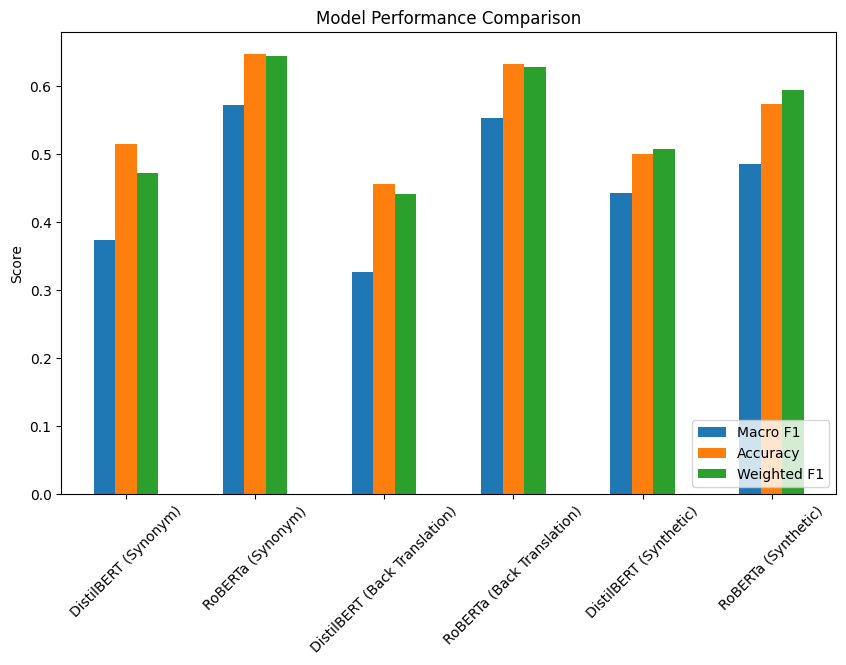

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Synonym Augmentation
wordnet_db_results = wordnet_trainer_db.evaluate()
wordnet_rb_results = wordnet_trainer_rb.evaluate()

# 2. Backtranslation Augmentation
bt_db_results = bt_trainer_db.evaluate()
bt_rb_results = bt_trainer_rb.evaluate()

# 3. Synthetic Data
ft_db_results = trainer_db.evaluate()
ft_rb_results = trainer_rb.evaluate()

# Simplify keys for comparison
data = {
    "DistilBERT (Synonym)": [wordnet_db_results['eval_f1'], wordnet_db_results['eval_accuracy'], wordnet_db_results['eval_weighted f1']],
    "RoBERTa (Synonym)": [wordnet_rb_results['eval_f1'], wordnet_rb_results['eval_accuracy'], wordnet_rb_results['eval_weighted f1']],
    "DistilBERT (Back Translation)": [bt_db_results['eval_f1'], bt_db_results['eval_accuracy'], bt_db_results['eval_weighted f1']],
    "RoBERTa (Back Translation)": [bt_rb_results['eval_f1'], bt_rb_results['eval_accuracy'], bt_rb_results['eval_weighted f1']],
    "DistilBERT (Synthetic)": [ft_db_results['eval_f1'], ft_db_results['eval_accuracy'], ft_db_results['eval_weighted f1']],
    "RoBERTa (Synthetic)": [ft_rb_results['eval_f1'], ft_rb_results['eval_accuracy'], ft_rb_results['eval_weighted f1']]
}

comparison_df = pd.DataFrame(data, index=['Macro F1', 'Accuracy', 'Weighted F1'])

display(comparison_df)

# Plotting
comparison_df.T.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

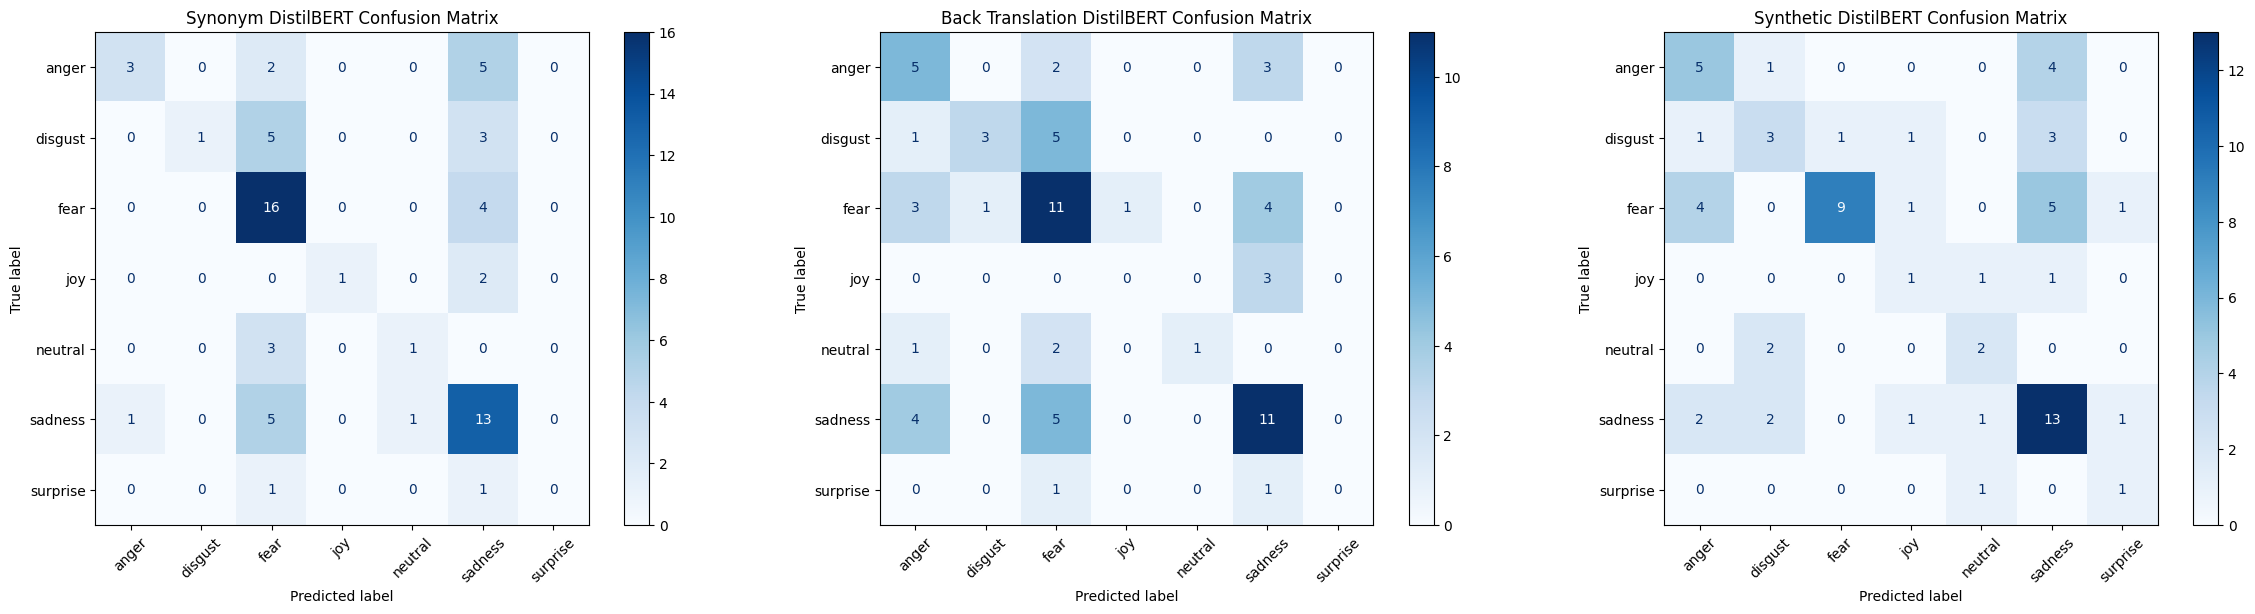

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(trainer, dataset):
    predictions = trainer.predict(dataset)
    return np.argmax(predictions.predictions, axis=-1)

# Get predictions

wordnet_db_preds = get_predictions(wordnet_trainer_db, val_db)
bt_db_preds = get_predictions(bt_trainer_db, val_db)
ft_db_preds = get_predictions(trainer_db, val_db)

# Get true labels from validation set
y_true = val_df['label_num'].values

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# DistilBERT wordnet
wn_db = confusion_matrix(y_true, wordnet_db_preds)
disp_wn = ConfusionMatrixDisplay(confusion_matrix=wn_db, display_labels=label_list)
disp_wn.plot(ax=ax1, cmap='Blues', xticks_rotation=45)
ax1.set_title("Synonym DistilBERT Confusion Matrix")

# DistilBERT back translation
bt_db = confusion_matrix(y_true, bt_db_preds)
disp_bt = ConfusionMatrixDisplay(confusion_matrix=bt_db, display_labels=label_list)
disp_bt.plot(ax=ax2, cmap='Blues', xticks_rotation=45)
ax2.set_title("Back Translation DistilBERT Confusion Matrix")

# DistilBERT synthetic
cm_db = confusion_matrix(y_true, ft_db_preds)
disp_db = ConfusionMatrixDisplay(confusion_matrix=cm_db, display_labels=label_list)
disp_db.plot(ax=ax3, cmap='Blues', xticks_rotation=45)
ax3.set_title("Synthetic DistilBERT Confusion Matrix")

# # RoBERTa CM
# cm_rb = confusion_matrix(y_true, ft_rb_preds)
# disp_rb = ConfusionMatrixDisplay(confusion_matrix=cm_rb, display_labels=label_list)
# disp_rb.plot(ax=ax2, cmap='Greens', xticks_rotation=45)
# ax2.set_title("Fine-tuned RoBERTa Confusion Matrix")

plt.tight_layout()
plt.show()

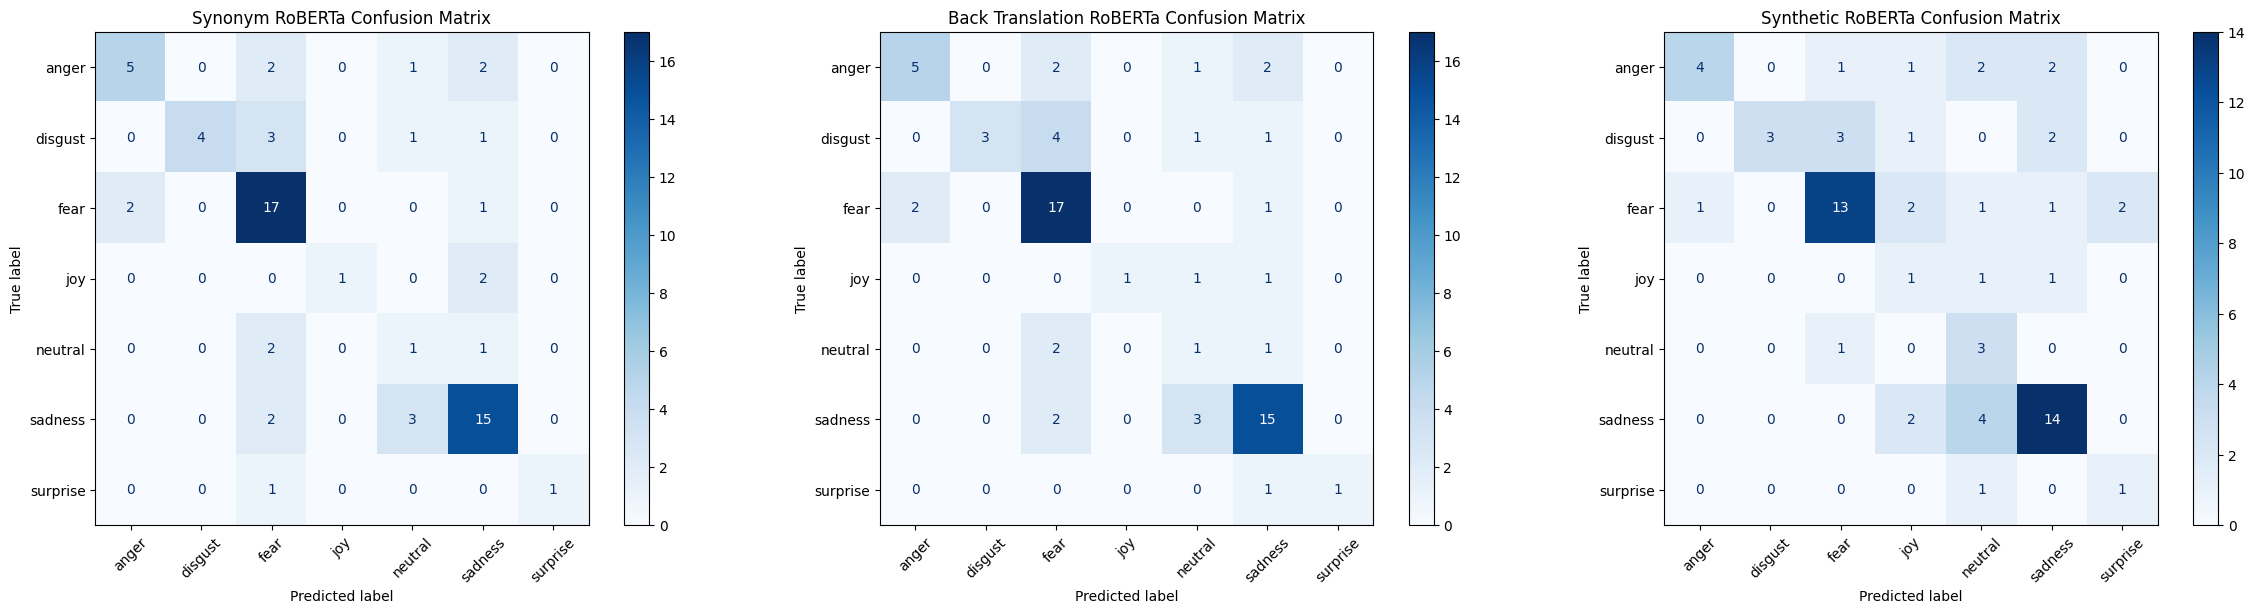

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(trainer, dataset):
    predictions = trainer.predict(dataset)
    return np.argmax(predictions.predictions, axis=-1)

# Get predictions

wordnet_rb_preds = get_predictions(wordnet_trainer_rb, val_rb)
bt_rb_preds = get_predictions(bt_trainer_rb, val_rb)
ft_rb_preds = get_predictions(trainer_rb, val_rb)

# Get true labels from validation set
y_true = val_df['label_num'].values

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# DistilBERT wordnet
wn_rb = confusion_matrix(y_true, wordnet_rb_preds)
disp_wn = ConfusionMatrixDisplay(confusion_matrix=wn_rb, display_labels=label_list)
disp_wn.plot(ax=ax1, cmap='Blues', xticks_rotation=45)
ax1.set_title("Synonym RoBERTa Confusion Matrix")

# DistilBERT back translation
bt_rb = confusion_matrix(y_true, bt_rb_preds)
disp_bt = ConfusionMatrixDisplay(confusion_matrix=bt_rb, display_labels=label_list)
disp_bt.plot(ax=ax2, cmap='Blues', xticks_rotation=45)
ax2.set_title("Back Translation RoBERTa Confusion Matrix")

# DistilBERT synthetic
cm_rb = confusion_matrix(y_true, ft_rb_preds)
disp_db = ConfusionMatrixDisplay(confusion_matrix=cm_rb, display_labels=label_list)
disp_db.plot(ax=ax3, cmap='Blues', xticks_rotation=45)
ax3.set_title("Synthetic RoBERTa Confusion Matrix")

plt.tight_layout()
plt.show()